# Python 与 LangGraph 交互式学习笔记

这份 Notebook 是 `python_langgraph_notes.md` 的配套版本：Markdown 单元负责解释概念，Code 单元负责演示可运行示例。

使用建议：

- 先顺序阅读 Markdown，再运行后面的代码单元。
- 大部分示例不需要真实大模型 API Key。
- DeepSeek 相关单元会显式读取项目根目录 `.env`，支持 `DEEPSEEK_API_KEY`，也兼容 OpenAI-style 的 `OPENAI_API_KEY` / `OPENAI_BASE_URL` / `OPENAI_MODEL`。
- 当前 LangGraph v1 之后推荐使用 `from langchain.agents import create_agent`，不要再用已弃用的 `langgraph.prebuilt.create_react_agent`。


## 1. LangGraph 是什么

LangGraph 是 LangChain 生态中用于构建有状态 Agent 和复杂 LLM 工作流的框架。

简单理解：

```text
LangChain 更偏组件：模型、Prompt、工具、链、检索器。
LangGraph 更偏编排：状态、节点、边、循环、暂停、恢复、多代理。
```

当你的应用需要工具调用、多轮状态、人工审批、流式过程、多 Agent 协作、恢复和调试时，LangGraph 就比单纯的链式调用更合适。


In [7]:
import operator
# 安装依赖示例。Notebook 中一般不自动执行安装命令。
# %pip install -U langgraph langchain langchain-deepseek langchain-openai python-dotenv

import os
from pathlib import Path

from dotenv import load_dotenv

# Notebook 的工作目录可能是 docs/，也可能是项目根目录。
# 这里向上查找 .env，确保能读到 D:/PythonProject/LearnOne/.env。
def find_project_env(start: Path | None = None) -> Path | None:
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        env_path = path / ".env"
        if env_path.exists():
            return env_path
    return None


env_path = find_project_env()
if env_path:
    load_dotenv(env_path, override=True)
    print(f"已加载环境变量：{env_path}")
else:
    print("没有找到 .env，真实模型调用单元会跳过。")

print("DEEPSEEK_API_KEY 已配置：", bool(os.getenv("DEEPSEEK_API_KEY")))
print("OPENAI_API_KEY 已配置：", bool(os.getenv("OPENAI_API_KEY")))
print("LangGraph 学习 Notebook 已加载。")


已加载环境变量：D:\PythonProject\LearnOne\.env
DEEPSEEK_API_KEY 已配置： True
OPENAI_API_KEY 已配置： True
LangGraph 学习 Notebook 已加载。


## 2.1 DeepSeek 连接自检

如果真实模型调用失败，先运行这个单元。它会用当前 `.env` 做一次最小 DeepSeek 请求，确认是配置问题、网络问题，还是接口临时 502。


In [8]:
import os
import time

from langchain_deepseek import ChatDeepSeek

# 这里强制使用 DeepSeek 官方分支，不读取 OPENAI_BASE_URL，避免误走 /anthropic 兼容地址。
model_name = os.getenv("DEEPSEEK_MODEL") or "deepseek-chat"
timeout = float(os.getenv("DEEPSEEK_TIMEOUT", "30"))

print("DEEPSEEK_API_KEY 已配置：", bool(os.getenv("DEEPSEEK_API_KEY")))
print("使用模型：", model_name)
print("DEEPSEEK_API_BASE：", os.getenv("DEEPSEEK_API_BASE") or "默认 DeepSeek 地址")
print("忽略 OPENAI_BASE_URL：", os.getenv("OPENAI_BASE_URL"))

try:
    start = time.time()
    check_model = ChatDeepSeek(
        model=model_name,
        api_key=os.getenv("DEEPSEEK_API_KEY"),
        base_url=os.getenv("DEEPSEEK_API_BASE"),
        temperature=0,
        timeout=timeout,
        max_retries=0,
    )
    result = check_model.invoke("只回答两个字：成功")
    print("连接成功，用时：", round(time.time() - start, 2), "秒")
    print("返回内容：", result.content)
except Exception as exc:
    print("连接失败。")
    print("错误类型：", type(exc).__name__)
    print("错误信息：", exc)
    print("如果是 502，多数是服务端网关临时错误，稍后重试即可。")


DEEPSEEK_API_KEY 已配置： True
使用模型： deepseek-chat
DEEPSEEK_API_BASE： 默认 DeepSeek 地址
忽略 OPENAI_BASE_URL： https://api.deepseek.com/anthropic
连接成功，用时： 0.72 秒
返回内容： 成功


## 2. DeepSeek + create_agent 基础写法

`create_agent` 是当前推荐的预构建 Agent 入口。这个单元只演示真实 DeepSeek 的普通对话调用，不绑定工具。

原因：真实模型的 tool calling 受模型、网关和接口兼容性影响，可能出现 502 等服务端错误。Notebook 里的工具调用和 context 会在后面的离线假模型单元演示，保证学习过程稳定。


In [9]:
import os

from langchain.agents import create_agent


def build_deepseek_model():
    """优先使用 langchain-deepseek，兼容 OpenAI-style DeepSeek 配置。"""

    # Notebook 里真实请求容易受网络影响，所以显式配置超时时间和重试次数。
    request_timeout = float(os.getenv("DEEPSEEK_TIMEOUT", "60"))
    max_retries = int(os.getenv("DEEPSEEK_MAX_RETRIES", "2"))

    # 方式一：优先读取 DeepSeek 官方环境变量。
    # 目录结构和 .env 已经配置好时，一般只需要保证 DEEPSEEK_API_KEY 存在。
    if os.getenv("DEEPSEEK_API_KEY"):
        from langchain_deepseek import ChatDeepSeek

        return ChatDeepSeek(
            # 模型名默认 deepseek-chat，也可以在 .env 里用 DEEPSEEK_MODEL 覆盖。
            model=os.getenv("DEEPSEEK_MODEL", "deepseek-chat"),
            api_key=os.getenv("DEEPSEEK_API_KEY"),
            # 温度越低，输出越稳定，适合教学和工具调用。
            temperature=float(os.getenv("DEEPSEEK_TEMPERATURE", "0")),
            # timeout 控制单次请求最长等待时间，避免网络慢时一直卡住。
            timeout=request_timeout,
            # max_retries 控制超时/网络波动时自动重试次数。
            max_retries=max_retries,
        )

    # 方式二：兼容 OpenAI-style 配置，适合把 DeepSeek 当 OpenAI 兼容接口使用。
    if os.getenv("OPENAI_API_KEY"):
        from langchain_openai import ChatOpenAI

        return ChatOpenAI(
            model=os.getenv("OPENAI_MODEL", "deepseek-chat"),
            api_key=os.getenv("OPENAI_API_KEY"),
            # DeepSeek 兼容接口地址，可在 .env 中通过 OPENAI_BASE_URL 覆盖。
            base_url=os.getenv("OPENAI_BASE_URL", "https://api.deepseek.com/v1"),
            temperature=0,
            timeout=request_timeout,
            max_retries=max_retries,
        )

    # 没有 key 时返回 None，后续单元用 if model 判断，避免 Notebook 直接报错。
    return None


model = build_deepseek_model()

if model is None:
    print("没有找到 DeepSeek/OpenAI-compatible API Key，跳过真实模型调用。")
else:
    # create_agent 会创建预构建 Agent。tools=[] 表示这里只演示普通模型回答。
    agent = create_agent(
        model=model,
        tools=[],
        system_prompt="你是一个简洁可靠的中文助手。",
    )

    try:
        # Agent 输入通常是 messages 字段，最后一条消息一般是最终回答。
        response = agent.invoke(
            {"messages": [{"role": "user", "content": "用一句话解释 LangGraph 是什么。"}]}
        )
        print(response["messages"][-1].content)
    except Exception as exc:
        # 超时通常是网络、代理、接口繁忙或 base_url 配置导致，不是 LangGraph 语法错误。
        print("真实模型请求失败，后续离线示例仍可继续学习。")
        print("错误类型：", type(exc).__name__)
        print("错误信息：", exc)
        print("可尝试：检查网络/代理/base_url，或在 .env 中调大 DEEPSEEK_TIMEOUT=120。")


LangGraph 是一个用于构建有状态、多步骤语言模型工作流的框架，支持通过图结构定义和编排复杂的 AI 代理逻辑。


## 3. Agent 输入输出

LangGraph / LangChain Agent 的常见输入是：

```python
{"messages": [{"role": "user", "content": "你好"}]}
```

输出通常也是一个字典，其中最常用的是 `messages`。如果配置了结构化输出，还会有 `structured_response`。


## 4. Context 上下文：把运行时信息安全传给工具

`context` 适合传用户 ID、租户、权限、语言偏好、请求来源等运行时信息。

重点：这些信息不是让模型自己编，而是由代码在 `agent.invoke(..., context=...)` 时传入，工具通过 `ToolRuntime[Context]` 读取。

下面这个例子不需要真实模型。它用一个离线假模型主动发起工具调用，从而完整演示 context 如何进入工具。真实 DeepSeek 工具调用可以参考项目里的 `langGraph/TestOne.py`，但 Notebook 里用离线模型避免接口 502 影响学习。


In [2]:
from __future__ import annotations

from collections.abc import Sequence
from dataclasses import dataclass
from typing import Any

from langchain.agents import create_agent
from langchain.tools import ToolRuntime, tool
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.runnables import Runnable
from langchain_core.tools import BaseTool


@dataclass
class Context:
    user_id: str


USER_PROFILES = {
    "U001": "张三，上海销售",
    "U002": "李四，北京财务",
}


@tool
def get_user_profile(runtime: ToolRuntime[Context]) -> str:
    """读取当前登录用户资料。"""

    user_id = runtime.context.user_id
    profile = USER_PROFILES.get(user_id, "未知用户")
    return f"当前用户 {user_id}：{profile}。"


class ContextDemoModel(BaseChatModel):
    """离线演示用模型：第一次请求工具，第二次总结工具结果。"""

    calls: int = 0

    @property
    def _llm_type(self) -> str:
        return "context-demo-model"

    def bind_tools(
        self,
        tools: Sequence[dict[str, Any] | type | BaseTool | Any],
        *,
        tool_choice: str | None = None,
        **kwargs: Any,
    ) -> Runnable:
        return self

    def _generate(
        self,
        messages: list[BaseMessage],
        stop: list[str] | None = None,
        run_manager: Any | None = None,
        **kwargs: Any,
    ) -> ChatResult:
        self.calls += 1
        if self.calls == 1:
            message = AIMessage(
                content="",
                tool_calls=[
                    {
                        "name": "get_user_profile",
                        "args": {},
                        "id": "call-get-user-profile",
                        "type": "tool_call",
                    }
                ],
            )
        else:
            tool_message = next(
                (message for message in reversed(messages) if message.type == "tool"),
                None,
            )
            content = f"工具返回：{tool_message.content if tool_message else '无工具结果'}"
            message = AIMessage(content=content)
        return ChatResult(generations=[ChatGeneration(message=message)])


context_agent = create_agent(
    model=ContextDemoModel(),
    tools=[get_user_profile],
    context_schema=Context,
    system_prompt="你是一个演示 runtime context 的助手。",
)

response = context_agent.invoke(
    {"messages": [{"role": "user", "content": "读取当前用户资料"}]},
    context=Context(user_id="U001"),
)

print(response["messages"][-1].content)


工具返回：当前用户 U001：张三，上海销售。


上面的 context 传递链路是：

```text
Context(user_id="U001")
-> agent.invoke(..., context=context)
-> Agent 执行 get_user_profile 工具
-> ToolRuntime[Context]
-> runtime.context.user_id
-> "U001"
```

这就是 context 的核心价值：把运行时信息安全地交给工具，而不是让模型自己猜。


## 5. StateGraph：状态、节点、边

LangGraph 的底层核心是图：

- `State`：当前状态快照。
- `Node`：处理状态的 Python 函数。
- `Edge`：决定下一步去哪个节点。

下面是最小状态图。


{'question': '什么是 LangGraph？', 'answer': '你问的是：什么是 LangGraph？'}


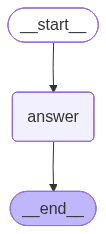

In [15]:
from typing_extensions import TypedDict

from langgraph.graph import END, START, StateGraph

class SimpleState(TypedDict):
    # question 是调用 graph.invoke 时传入的输入字段。
    question: str
    # answer 是 answer_node 执行后写入的输出字段。
    answer: str


def answer_node(state: SimpleState) -> dict[str, str]:
    # 节点接收完整 state，返回“局部状态更新”。
    # 注意：节点要返回 dict，而不是直接返回字符串。
    return {"answer": f"你问的是：{state['question']}"}


# 创建图构建器，并声明状态结构。
builder = StateGraph(SimpleState)

# 注册节点：节点名 answer，对应函数 answer_node。
builder.add_node("answer", answer_node)

# START 是图入口，表示运行后第一步进入 answer。
builder.add_edge(START, "answer")

# answer 执行完进入 END，表示流程结束。
builder.add_edge("answer", END)

# compile 后才得到可运行的 graph。
simple_graph = builder.compile()

# 传入初始 state，图会从 START 开始执行。
result = simple_graph.invoke({"question": "什么是 LangGraph？"})
print(result)

from IPython.display import Image, display

display(Image(simple_graph.get_graph().draw_mermaid_png()))


## 6. 条件边：根据状态决定下一步

固定边适合线性流程，条件边适合分支流程。下面的图会根据 `score` 判断走 `pass_node` 还是 `fail_node`。


{'score': 88, 'result': '通过'}
{'score': 42, 'result': '未通过'}


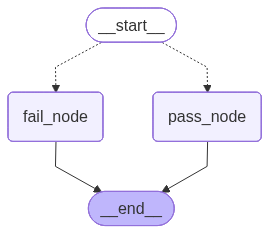

In [16]:
from typing import Literal
from typing_extensions import TypedDict

from langgraph.graph import END, START, StateGraph


class ScoreState(TypedDict):
    # 输入分数。
    score: int
    # 路由后的结果。
    result: str


def route_by_score(state: ScoreState) -> Literal["pass_node", "fail_node"]:
    # 条件边函数只负责返回下一个节点名。
    return "pass_node" if state["score"] >= 60 else "fail_node"


def pass_node(state: ScoreState) -> dict[str, str]:
    # 通过分支写入 result。
    return {"result": "通过"}


def fail_node(state: ScoreState) -> dict[str, str]:
    # 未通过分支写入 result。
    return {"result": "未通过"}


builder = StateGraph(ScoreState)

# 从 START 出发时，不走固定边，而是调用 route_by_score 判断进入哪个节点。
builder.add_conditional_edges(START, route_by_score)

# 注册两个分支节点。
builder.add_node("pass_node", pass_node)
builder.add_node("fail_node", fail_node)

# 两个分支最终都结束。
builder.add_edge("pass_node", END)
builder.add_edge("fail_node", END)

score_graph = builder.compile()
print(score_graph.invoke({"score": 88, "result": ""}))
print(score_graph.invoke({"score": 42, "result": ""}))

from IPython.display import Image, display
display(Image(score_graph.get_graph().draw_mermaid_png()))


## 6.1 流程图可视化：Mermaid PNG

LangGraph 编译后的图可以直接可视化。常用方式：

- `graph.get_graph().draw_mermaid()`：输出 Mermaid 文本，不需要额外安装组件。
- `graph.get_graph().draw_mermaid_png()`：生成 PNG，适合在 Notebook 里直接显示，当前环境已可运行。
- `graph.get_graph().print_ascii()`：需要 `grandalf`，只适合终端字符图。
- `graph.get_graph().draw_png()`：通常需要 `pygraphviz` / Graphviz，本地安装成本更高。

所以学习阶段推荐先用 Mermaid：不额外安装也能看到结构；需要图片时用 `draw_mermaid_png()`。下面这个例子会画出类似“识别审批类型 -> 条件分支 -> 抽取字段”的流程图。


{'input': '我要报销差旅费', 'review_type': 'expense', 'status': '报销子流程 -> 抽取字段'}
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	DeepSeek\20\8bc6\522b\5ba1\6279\7c7b\578b(DeepSeek 识别审批类型)
	\8bf7\5047\5b50\6d41\7a0b(请假子流程)
	\62a5\9500\5b50\6d41\7a0b(报销子流程)
	\91c7\8d2d\5b50\6d41\7a0b(采购子流程)
	\6ca1\6709\5ba1\6279\7c7b\578b(没有审批类型)
	\62bd\53d6\5b57\6bb5(抽取字段)
	__end__([<p>__end__</p>]):::last
	DeepSeek\20\8bc6\522b\5ba1\6279\7c7b\578b -. &nbsp;expense&nbsp; .-> \62a5\9500\5b50\6d41\7a0b;
	DeepSeek\20\8bc6\522b\5ba1\6279\7c7b\578b -. &nbsp;unknown&nbsp; .-> \6ca1\6709\5ba1\6279\7c7b\578b;
	DeepSeek\20\8bc6\522b\5ba1\6279\7c7b\578b -. &nbsp;leave&nbsp; .-> \8bf7\5047\5b50\6d41\7a0b;
	DeepSeek\20\8bc6\522b\5ba1\6279\7c7b\578b -. &nbsp;purchase&nbsp; .-> \91c7\8d2d\5b50\6d41\7a0b;
	__start__ --> DeepSeek\20\8bc6\522b\5ba1\6279\7c7b\578b;
	\62a5\9500\5b50\6d41\7a0b --> \62bd\53d6\5b57\6bb5;
	\6ca1\6709\5ba1\6279\7c7b\578b --> \62bd\53d6\5b57\6bb5;
	\8bf

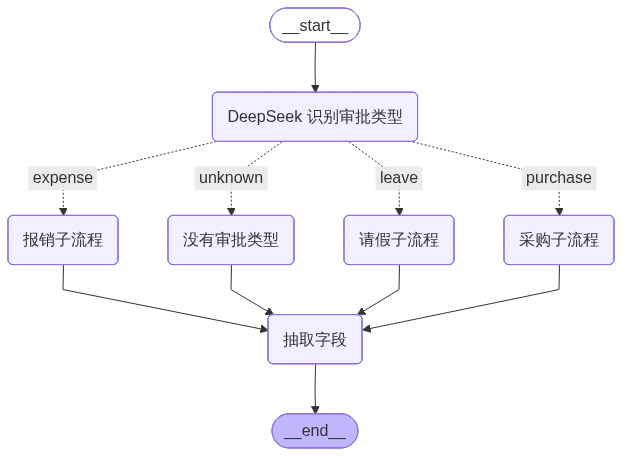

In [14]:
from typing import Literal
from typing_extensions import TypedDict

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


class ReviewFlowState(TypedDict):
    # 用户原始输入。
    input: str
    # DeepSeek 或规则识别出的审批类型。
    review_type: str
    # 当前流程状态。
    status: str


def classify_review_type(state: ReviewFlowState) -> dict[str, str]:
    # 学习演示里不真实调用 DeepSeek，直接使用输入 state 里的 review_type。
    # 真实项目可以在这里调用大模型，把自然语言识别成 leave / expense / purchase / unknown。
    return {"review_type": state.get("review_type", "unknown")}


def route_review_type(state: ReviewFlowState) -> Literal["leave", "expense", "purchase", "unknown"]:
    # 条件边函数只返回路由标签，LangGraph 会根据 mapping 找到下一个节点。
    return state["review_type"]


def leave_flow(state: ReviewFlowState) -> dict[str, str]:
    return {"status": "请假子流程"}


def expense_flow(state: ReviewFlowState) -> dict[str, str]:
    return {"status": "报销子流程"}


def purchase_flow(state: ReviewFlowState) -> dict[str, str]:
    return {"status": "采购子流程"}


def unknown_flow(state: ReviewFlowState) -> dict[str, str]:
    return {"status": "没有审批类型"}


def extract_fields(state: ReviewFlowState) -> dict[str, str]:
    return {"status": state["status"] + " -> 抽取字段"}


review_builder = StateGraph(ReviewFlowState)
review_builder.add_node("DeepSeek 识别审批类型", classify_review_type)
review_builder.add_node("请假子流程", leave_flow)
review_builder.add_node("报销子流程", expense_flow)
review_builder.add_node("采购子流程", purchase_flow)
review_builder.add_node("没有审批类型", unknown_flow)
review_builder.add_node("抽取字段", extract_fields)

review_builder.add_edge(START, "DeepSeek 识别审批类型")
review_builder.add_conditional_edges(
    "DeepSeek 识别审批类型",
    route_review_type,
    {
        "leave": "请假子流程",
        "expense": "报销子流程",
        "purchase": "采购子流程",
        "unknown": "没有审批类型",
    },
)
for node_name in ["请假子流程", "报销子流程", "采购子流程", "没有审批类型"]:
    review_builder.add_edge(node_name, "抽取字段")
review_builder.add_edge("抽取字段", END)

review_flow_graph = review_builder.compile()

print(review_flow_graph.invoke({"input": "我要报销差旅费", "review_type": "expense", "status": ""}))

# 方式一：查看 Mermaid 文本。复制到 Mermaid Live Editor 也能渲染。
print(review_flow_graph.get_graph().draw_mermaid())

# 方式二：在 Notebook 中直接显示 PNG。
display(Image(review_flow_graph.get_graph().draw_mermaid_png()))


## 7. State reducer：让列表追加而不是覆盖

默认情况下，节点返回的新字段会覆盖旧值。对于消息列表、日志列表这类字段，通常希望追加。可以用 `Annotated[..., reducer]` 指定合并方式。


{'logs': ['开始', '执行 step_one', '执行 step_two']}


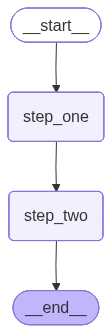

In [19]:
import operator
from typing import Annotated
# from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langgraph.graph import END, START, StateGraph


# class LogState(TypedDict):
#     # Annotated[list[str], add] 表示多个节点返回 logs 时使用 add 合并。
#     # 对 list 来说，operator.add 等价于列表拼接，而不是覆盖。
#     logs: Annotated[list[str], add]

# 1. 使用 Pydantic 定义状态模型
class LogState(BaseModel):
    # 在 Pydantic 中，通过 Field(default_factory=list) 指定默认值
    # 同时使用 Annotated 和来自 operator.add 的 reducer 控制 LangGraph 的合并行为
    logs: Annotated[list[str], operator.add] = Field(default_factory=list)


def step_one(state: LogState) -> dict[str, list[str]]:
    # 返回新的日志片段，reducer 会追加到旧 logs 后面。
    return {"logs": ["执行 step_one"]}


def step_two(state: LogState) -> dict[str, list[str]]:
    return {"logs": ["执行 step_two"]}


builder = StateGraph(LogState)
builder.add_node("step_one", step_one)
builder.add_node("step_two", step_two)

# 串行流程：START -> step_one -> step_two -> END。
builder.add_edge(START, "step_one")
builder.add_edge("step_one", "step_two")
builder.add_edge("step_two", END)

log_graph = builder.compile()
result = log_graph.invoke({"logs": ["开始"]})
print(result)

from IPython.display import Image, display
display(Image(log_graph.get_graph().draw_mermaid_png()))


## 8. 持久化：checkpointer + thread_id

短期记忆依赖检查点。核心是：

- 创建图时传入 `checkpointer`。
- 调用图时传入 `config={"configurable": {"thread_id": "..."}}`。
- 相同 `thread_id` 会接上同一条线程。


In [24]:
from operator import add
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph


# class MemoryState(TypedDict):
#     # events 使用 add reducer，新的事件会追加到旧事件列表。
#     events: Annotated[list[str], add]

class MemoryState(BaseModel):
    events: Annotated[list[str], operator.add] = Field(default_factory=list)


def remember_node(state: MemoryState) -> dict[str, list[str]]:
    # 每次执行节点都追加一条事件。
    return {"events": ["本轮执行了一次"]}


builder = StateGraph(MemoryState)
builder.add_node("remember", remember_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

# compile 时加入 checkpointer，图就能按 thread_id 保存状态。
memory_graph = builder.compile(checkpointer=InMemorySaver())

# 同一个 thread_id 表示同一个线程/会话。
config = {"configurable": {"thread_id": "demo-thread"}}

first = memory_graph.invoke({"events": ["开始"]}, config=config)
second = memory_graph.invoke({"events": ["继续"]}, config=config)

config_one = {"configurable": {"thread_id": "demo-thread-two"}}
third = memory_graph.invoke({"events": ["再次继续"]}, config=config_one)

four = memory_graph.invoke({"events": ["最后继续"]}, config=config)

print("第一次：", first)
print("第二次：", second)
print("第三次 不同thread的", third)
print("第四次", four)


第一次： {'events': ['开始', '本轮执行了一次']}
第二次： {'events': ['开始', '本轮执行了一次', '继续', '本轮执行了一次']}
第三次 不同thread的 {'events': ['再次继续', '本轮执行了一次']}
第四次 {'events': ['开始', '本轮执行了一次', '继续', '本轮执行了一次', '最后继续', '本轮执行了一次']}


## 8.1 DeepSeek + MessagesState：最小聊天图

这个例子对应图片里的“线程隔离的持久化层”前置代码：先创建一个最小的 `MessagesState` 图，节点负责调用 DeepSeek，并把模型回复追加回 `messages`。

注意：这里使用你的 `DEEPSEEK_API_KEY` 和 `DEEPSEEK_API_BASE`。如果你的 `DEEPSEEK_API_BASE` 已经包含 `/v1`，就不要再额外拼接 `/v1`。


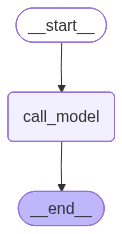

--- 开始流式执行图 ---

[节点 'call_model' 执行完毕，吐出数据]：
================================== Ai Message ==================================

你好！我是DeepSeek，由深度求索公司创造的AI助手。很高兴认识你！😊

我是一个纯文本模型，可以帮你解答各种问题、进行对话、处理文档等等。虽然我不支持多模态识别（比如直接识别图片内容），但我可以读取你上传的图像、PDF、Word、Excel等文件中的文字信息来帮助你。

而且我完全免费使用，拥有1M的超长上下文（相当于可以一次性处理《三体》三部曲那么多的内容！），还支持联网搜索功能（需要手动开启）。

有什么我可以帮你的吗？无论是学习、工作还是日常问题，尽管问我！💪


In [2]:
import os
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import END, START, MessagesState, StateGraph
from IPython.display import Image, display

# 读取环境配置
load_dotenv(override=True)

request_timeout = float(os.getenv("DEEPSEEK_TIMEOUT", "60"))
max_retries = int(os.getenv("DEEPSEEK_MAX_RETRIES", "2"))

# 初始化 DeepSeek 模型
model = ChatDeepSeek(
    model=os.getenv("DEEPSEEK_MODEL", "deepseek-chat"),
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
    timeout=request_timeout,
    max_retries=max_retries,
)

# 定义节点
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

# 构建图
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", END)

chat_graph = builder.compile()

# 在 Notebook 中展示流程图
display(Image(chat_graph.get_graph().draw_mermaid_png()))

# --- 核心修改部分：使用 stream 进行流式输出并配合 pretty_print ---

# 准备初始输入
initial_input = {"messages": [{"role": "user", "content": "hi 你是谁？"}]}

try:
    print("--- 开始流式执行图 ---")

    # 1. 使用 graph.stream 代替 graph.invoke
    # stream_mode="updates" 表示每当有节点更新状态时，就产出（yield）一次数据
    for chunk in chat_graph.stream(initial_input, stream_mode="updates"):

        # chunk 的结构通常是: {"节点名": {"状态键": 状态值}}
        # 例如: {"call_model": {"messages": [AIMessage(...)]}}
        for node_name, response_dict in chunk.items():
            print(f"\n[节点 '{node_name}' 执行完毕，吐出数据]：")

            # 2. 提取出节点返回的消息列表
            if "messages" in response_dict:
                for msg in response_dict["messages"]:
                    # 3. 使用 LangChain 内置的 pretty_print() 进行美化打印
                    msg.pretty_print()

except Exception as exc:
    print("\n真实 DeepSeek 请求失败，图结构已经创建成功。")
    print("错误类型：", type(exc).__name__)
    print("错误信息：", exc)

## 8.2 线程隔离的持久化层

`checkpointer` 会保存图执行过程中的中间状态。调用时传入 `thread_id` 后，相同线程会接着之前的消息历史继续，不同线程互相隔离。

图片里写的是 `MemorySaver`，在当前版本里它就是 `InMemorySaver` 的别名。学习阶段可以用内存版；生产环境要换成数据库或 LangGraph Platform 的持久化能力。


In [3]:
from langgraph.checkpoint.memory import InMemorySaver

# InMemorySaver 是内存检查点，适合 Notebook 演示。
memory = InMemorySaver()

# persistent_graph 和上面的 chat_graph 逻辑一样，只是多了持久化能力。
persistent_graph = builder.compile(checkpointer=memory)

# thread_id 决定这次运行属于哪条对话线程。
config = {"configurable": {"thread_id": "thread-1"}}
input_message = {"role": "user", "content": "hi! 我是 KangKang"}

try:
    for chunk in persistent_graph.stream(
        {"messages": [input_message]},
        config=config,
        # values 表示每次返回完整状态快照，便于观察 messages 变化。
        stream_mode="values",
    ):
        chunk["messages"][-1].pretty_print()
except Exception as exc:
    print("真实模型请求失败，但持久化图已经创建成功。")
    print("错误类型：", type(exc).__name__)
    print("错误信息：", exc)


================================ Human Message =================================

hi! 我是 KangKang
================================== Ai Message ==================================

嗨，KangKang！很高兴认识你！😊 有什么我可以帮你的吗？无论是聊天、解答问题，还是需要一些建议，我都在这里！


In [4]:
# 同一个 thread_id 会保留上一轮上下文。
try:
    for chunk in persistent_graph.stream(
        {"messages": [{"role": "user", "content": "我刚才告诉你我叫什么？"}]},
        config=config,
        stream_mode="values",
    ):
        chunk["messages"][-1].pretty_print()
except Exception as exc:
    print("真实模型请求失败，通常是接口超时或网络问题。")
    print("错误类型：", type(exc).__name__)
    print("错误信息：", exc)


================================ Human Message =================================

我刚才告诉你我叫什么？
================================== Ai Message ==================================

哈哈，你刚才告诉我你叫 **KangKang** 呀！😄 放心，我会记住的～ 有什么需要帮忙的吗？


In [5]:
# 换一个 thread_id，就是另一条独立线程。
other_config = {"configurable": {"thread_id": "thread-2"}}

for chunk in persistent_graph.stream(
    {"messages": [{"role": "user", "content": "我刚才告诉你我叫什么？"}]},
    config=other_config,
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()


================================ Human Message =================================

我刚才告诉你我叫什么？
================================== Ai Message ==================================

您还没有告诉我您的名字呢！😊 如果您愿意分享，我可以记住您告诉我的称呼，方便我们后续交流。您想让我怎么称呼您呢？


## 8.3 跨线程共享长期记忆

`thread_id` 解决的是“同一条会话线程”的短期记忆。长期记忆通常要按 `user_id` 存储，这样不同线程也能共享用户资料。

下面先给一个离线可运行的 `InMemoryStore` 例子：不需要 embedding，不需要调用模型，只演示 `user_id -> memory` 的读写。


In [6]:
from langgraph.store.memory import InMemoryStore

# InMemoryStore 用来演示长期记忆；数据只存在当前进程内。
store = InMemoryStore()

user_id = "user-kangkang"

# namespace 用来隔离不同用户或不同记忆类型。
namespace = ("memories", user_id)

# 写入一条用户画像记忆。
store.put(
    namespace,
    "profile",
    {"text": "Kangkang 喜欢 Python，也在学习 LangGraph。"},
)

# 写入一条偏好记忆。
store.put(
    namespace,
    "preference",
    {"text": "Kangkang 希望示例尽量使用 DeepSeek。"},
)

# 读取该 namespace 下的所有记忆。
memories = store.search(namespace)
for item in memories:
    print(item.key, item.value)


profile {'text': 'Kangkang 喜欢 Python，也在学习 LangGraph。'}
preference {'text': 'Kangkang 希望示例尽量使用 DeepSeek。'}


如果你的网关支持 OpenAI 兼容的 embedding 接口，也可以给 `InMemoryStore` 配置索引。图片里类似使用 `OpenAIEmbeddings(model="Pro/BAAI/bge-m3")`，这里保留 DeepSeek/兼容网关写法。运行前请确认你的 `DEEPSEEK_API_BASE` 是否提供 embedding 模型。


In [7]:
# 可选：带 embedding 索引的长期记忆。
# 如果你的 DEEPSEEK_API_BASE 不支持 embedding，请跳过这个单元。
import os
from langchain_openai import OpenAIEmbeddings
from langgraph.store.memory import InMemoryStore

embedding_store = InMemoryStore(
    index={
        "embed": OpenAIEmbeddings(
            model="Pro/BAAI/bge-m3",
            api_key=os.environ.get("DEEPSEEK_API_KEY"),
            base_url=os.environ.get("DEEPSEEK_API_BASE"),
        ),
        "dims": 1024,
    }
)

embedding_store.put(
    ("memories", "user-tomie"),
    "langgraph",
    {"text": "Tomie 正在学习 LangGraph 的持久化和人机交互。"},
)

embedding_store.search(("memories", "user-tomie"), query="用户在学什么？")


NotFoundError: Error code: 404

## 8.4 短期记忆：最小 ReAct 图

这一组图展示的是一个最小 ReAct 智能体：

- `agent` 节点调用模型。
- 如果模型返回 `tool_calls`，条件边走到 `action`。
- `action` 使用 `ToolNode` 执行工具。
- 工具结果回到 `agent`，直到模型不再调用工具。

这里的 `search` 是一个模拟工具，不会真的联网。


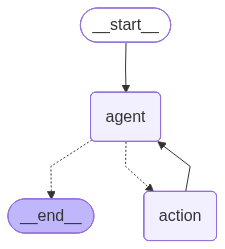

In [9]:
from typing import Literal

from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode


@tool
def search(query: str) -> str:
    """调用此函数可以浏览网络。"""
    # 这里是离线模拟结果，真实项目可以替换成搜索 API。
    return "北京天气晴朗，大约22度，湿度30%。"


# ToolNode 负责真正执行模型请求的工具调用。
tools = [search]
tool_node = ToolNode(tools)

# bind_tools 后，模型才知道可以调用哪些工具。
bound_model = model.bind_tools(tools)


def should_continue(state: MessagesState) -> Literal["action", "__end__"]:
    """根据最后一条 AI 消息是否包含 tool_calls 决定下一步。"""
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return END
    return "action"


def call_react_model(state: MessagesState):
    # 调用绑定工具后的模型，模型可能返回 tool_calls。
    response = bound_model.invoke(state["messages"])
    return {"messages": [response]}


workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_react_model)
workflow.add_node("action", tool_node)
workflow.add_edge(START, "agent")

# agent 后面走条件边：需要工具就去 action，否则结束。
workflow.add_conditional_edges("agent", should_continue, ["action", END])

# 工具执行完再回到 agent，让模型观察工具结果并继续回答。
workflow.add_edge("action", "agent")

react_graph = workflow.compile(checkpointer=InMemorySaver())

from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [10]:
react_config = {"configurable": {"thread_id": "react-thread-1"}}

try:
    for chunk in react_graph.stream(
        {"messages": [{"role": "user", "content": "北京天气怎么样？需要的话可以搜索。"}]},
        config=react_config,
        stream_mode="values",
    ):
        chunk["messages"][-1].pretty_print()
except Exception as exc:
    print("真实模型请求失败，ReAct 图结构仍可作为代码学习参考。")
    print("错误类型：", type(exc).__name__)
    print("错误信息：", exc)


================================ Human Message =================================

北京天气怎么样？需要的话可以搜索。
================================== Ai Message ==================================

好的，我来查一下北京的天气情况。
Tool Calls:
  search (call_00_ZwdK7ClM47N0DPbDaf2V6510)
 Call ID: call_00_ZwdK7ClM47N0DPbDaf2V6510
  Args:
    query: 北京天气 今天
================================= Tool Message =================================
Name: search

北京天气晴朗，大约22度，湿度30%。
================================== Ai Message ==================================

北京今天天气**晴朗**，气温大约 **22°C**，湿度 **30%**，整体感觉比较舒适。

不过天气信息变化较快，建议您关注实时天气预报，以便获取最新、最准确的数据。如果您需要更详细的天气信息（比如风力、未来几天的预报等），也可以告诉我，我再帮您查一下！


## 8.5 优化记忆

长对话不能无限把所有历史消息塞给模型。常见做法有两类：

- 消息过滤：对旧消息做删除、裁剪或编辑，防止上下文爆炸。
- 消息总结：把旧消息压缩成摘要，保留关键信息。

记忆管理本质上是在“召回率”和“精度”之间做平衡：保留太少会忘事，保留太多会增加成本并干扰回答。


In [11]:
from langchain_core.messages import AIMessage, HumanMessage, RemoveMessage, SystemMessage

old_messages = [
    HumanMessage(content="我叫 Kangkang。"),
    AIMessage(content="你好 Kangkang。"),
    HumanMessage(content="我喜欢 Python。"),
    AIMessage(content="记住了，你喜欢 Python。"),
    HumanMessage(content="我正在学习 LangGraph。"),
]

# 过滤策略：删除较早消息，只保留最近两条。
remove_old_messages = [RemoveMessage(id=message.id) for message in old_messages[:-2]]
kept_messages = old_messages[-2:]

print("要删除的消息数量：", len(remove_old_messages))
print("保留的消息：")
for message in kept_messages:
    message.pretty_print()

# 总结策略：把历史压缩成一条系统消息。
summary_message = SystemMessage(
    content="对话摘要：用户叫 Tomie，喜欢 Python，正在学习 LangGraph。"
)
summary_message.pretty_print()


要删除的消息数量： 3
保留的消息：
================================== Ai Message ==================================

记住了，你喜欢 Python。
================================ Human Message =================================

我正在学习 LangGraph。
================================ System Message ================================

对话摘要：用户叫 Tomie，喜欢 Python，正在学习 LangGraph。


## 8.6 人机交互：审查工具调用

这个例子演示的是“工具真正执行之前，先让人检查一下”。真实业务里很常见，比如：

- AI 准备调用“提交审批”工具，但需要用户先确认。
- AI 准备调用“搜索/查询”工具，但参数可能不准确，需要人工改一下。
- AI 给出一个工具调用计划，人可以批准、修改参数，或者把反馈交回模型重新生成。

本例的流程是：

1. 用户问“帮我查北京天气”。
2. `call_llm` 节点模拟模型生成一个工具调用：`review_search(query="北京天气")`。
3. `human_review` 节点通过 `interrupt(...)` 暂停，把工具名和参数交给人审查。
4. 人通过 `Command(resume=...)` 恢复图执行。
5. 如果选择 `continue`，直接执行工具；如果选择 `update`，先改工具参数再执行；如果选择 `feedback`，把反馈作为 `ToolMessage` 交回模型重新思考。

注意：带 `checkpointer` 的图会按 `thread_id` 保存状态。重复运行同一个 `thread_id` 的起始 cell 时，可能会把新的 `HumanMessage` 追加到已有会话末尾，所以审查节点应查找最近一条带 `tool_calls` 的 `AIMessage`，不要直接假设 `messages[-1]` 一定是 AI 消息。


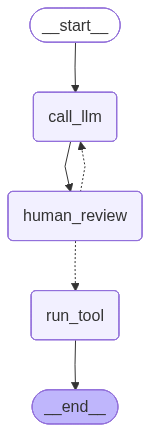

In [19]:
from typing import Literal

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, interrupt


@tool
def review_search(query: str) -> str:
    """模拟搜索工具。

    真实项目里这里可能是：
    - 搜索知识库
    - 查询天气 API
    - 查询审批系统
    - 提交某个业务动作

    这里为了离线稳定运行，不访问外部服务，直接返回固定文本。
    """
    return f"搜索结果：{query} -> 北京天气晴朗，约22度，湿度30%。"


# ToolNode 是 LangGraph 预置节点。
# 它会读取上一条 AIMessage 里的 tool_calls，找到对应工具并执行。
review_tools = [review_search]
review_tool_node = ToolNode(review_tools)


class ReviewState(MessagesState):
    """本例只需要 messages 状态。

    MessagesState 内置了 messages 字段，并且会自动把每个节点返回的消息追加到历史中。
    所以整个图里的消息会像这样增长：
    HumanMessage -> AIMessage(tool_calls=...) -> ToolMessage
    """


def call_llm_for_review(state: ReviewState):
    """模拟 LLM 生成一个工具调用。

    正常情况下，这里会调用真实模型，例如：
    model_with_tools.invoke(state["messages"])

    为了让 notebook 不依赖网络和模型稳定性，这里手写一个 AIMessage。
    关键点是 tool_calls：它表示 AI 想调用哪个工具，以及传什么参数。
    """
    return {
        "messages": [
            AIMessage(
                content="我需要查询天气。",
                id="ai-search-request",
                tool_calls=[
                    {
                        # 工具名必须和 @tool 注册出来的名字一致。
                        "name": "review_search",
                        # args 是准备传给工具的参数。
                        "args": {"query": "北京天气"},
                        # id 用来把工具调用和 ToolMessage 对应起来。
                        "id": "call_search_1",
                        "type": "tool_call",
                    }
                ],
            )
        ]
    }


def human_review_node(
    state: ReviewState,
) -> Command[Literal["call_llm", "run_tool"]]:
    """人工审查节点。

    这个节点的职责不是执行工具，而是在工具执行前暂停，让人决定：
    1. continue：工具参数没问题，继续执行工具。
    2. update：工具名没问题，但参数要改一下，再执行工具。
    3. feedback：这个工具调用不合适，把反馈交回模型重新生成。
    """

    # interrupted 图可能因为重复运行同一个 thread_id，把新的 HumanMessage 追加到消息末尾。
    # 因此这里不能直接取 messages[-1].tool_calls，而要向前找最近的工具调用消息。
    last_message = next(
        (
            message
            for message in reversed(state["messages"])
            if isinstance(message, AIMessage) and message.tool_calls
        ),
        None,
    )
    if last_message is None:
        raise ValueError("没有找到待人工审查的工具调用，请先运行 call_llm 节点生成 tool_calls。")

    # 本例只有一个工具调用，所以取最后一个即可。
    # 如果一个 AIMessage 里有多个工具调用，可以在这里循环审查。
    tool_call = last_message.tool_calls[-1]

    # interrupt 会让图暂停，并把这个字典返回给调用方。
    # notebook 里 first_result["__interrupt__"] 看到的就是这里传出去的内容。
    human_review = interrupt(
        {
            "question": "这个工具调用正确吗？",
            "tool_call": tool_call,
        }
    )

    # 当外部调用 Command(resume={...}) 时，interrupt 会返回 resume 里的数据。
    # 所以 human_review 就是类似：{"action": "continue"} 的字典。
    review_action = human_review["action"]
    review_data = human_review.get("data")

    if review_action == "continue":
        # 批准：不修改 state，直接跳到 run_tool。
        # run_tool 是 ToolNode，会执行 AIMessage 里的 review_search(query="北京天气")。
        return Command(goto="run_tool")

    if review_action == "update":
        # 修改参数：把原来的 tool_calls 替换成审查后的参数。
        # 例如把 {"query": "北京天气"} 改成 {"query": "北京今天实时天气"}。
        updated_message = AIMessage(
            content=last_message.content,
            id=last_message.id,
            tool_calls=[
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],
                    "args": review_data,
                    "type": "tool_call",
                }
            ],
        )
        return Command(
            goto="run_tool",
            # update 会把这条新的 AIMessage 追加到 messages 中。
            # ToolNode 会读取最近的工具调用消息，因此会执行更新后的参数。
            update={"messages": [updated_message]},
        )

    if review_action == "feedback":
        # 反馈给模型：不执行工具，而是构造 ToolMessage 告诉模型“这个工具调用哪里不对”。
        # 然后跳回 call_llm，让模型基于反馈重新生成工具调用。
        feedback_message = ToolMessage(
            content=review_data,
            tool_call_id=tool_call["id"],
        )
        return Command(
            goto="call_llm",
            update={"messages": [feedback_message]},
        )

    raise ValueError(f"未知审查动作：{review_action}")


# 1. 创建图。
review_workflow = StateGraph(ReviewState)

# 2. 注册三个节点：
# - call_llm：生成工具调用
# - human_review：人工审查工具调用
# - run_tool：真正执行工具
review_workflow.add_node("call_llm", call_llm_for_review)
review_workflow.add_node("human_review", human_review_node)
review_workflow.add_node("run_tool", review_tool_node)

# 3. 定义边：开始 -> 模型 -> 人审 -> 工具 -> 结束。
# human_review 节点内部会通过 Command(goto=...) 决定下一步去哪里。
review_workflow.add_edge(START, "call_llm")
review_workflow.add_edge("call_llm", "human_review")
review_workflow.add_edge("run_tool", END)

# 4. 编译图。
# checkpointer 是必须的，因为 interrupt 暂停后，需要用同一个 thread_id 恢复现场。
review_graph = review_workflow.compile(checkpointer=InMemorySaver())

from IPython.display import Image, display

# 画出图结构，方便理解节点关系。
display(Image(review_graph.get_graph().draw_mermaid_png()))


In [23]:
# 第一次运行：图会执行到 human_review_node，然后在 interrupt(...) 处暂停。
# thread_id 用来标识一次会话。后续 resume 必须使用同一个 thread_id。
review_config = {"configurable": {"thread_id": "human-review-demo"}}

first_result = review_graph.invoke(
    {"messages": [HumanMessage(content="帮我查北京天气")]},
    config=review_config,
)

# __interrupt__ 里能看到 human_review_node 交给人工审查的内容。
# 这里会包含 question 和准备执行的 tool_call。
first_result["__interrupt__"]


[Interrupt(value={'question': '这个工具调用正确吗？', 'tool_call': {'name': 'review_search', 'args': {'query': '北京天气'}, 'id': 'call_search_1', 'type': 'tool_call'}}, id='93ef43955665a3f9214275c3a36ad071')]

In [24]:
# 方式一：批准，直接执行工具。
# 这一步会从刚才 interrupt 暂停的位置继续运行。
# action="continue" 表示：工具名和参数都没问题，直接去 run_tool 节点。
review_graph.invoke(
    Command(resume={"action": "continue"}),
    config=review_config,
)


{'messages': [HumanMessage(content='帮我查北京天气', additional_kwargs={}, response_metadata={}, id='fd4f2337-cdb6-4f5a-b1c9-93dd0d92128e'),
  AIMessage(content='我需要查询天气。', additional_kwargs={}, response_metadata={}, id='ai-search-request', tool_calls=[{'name': 'review_search', 'args': {'query': '北京天气'}, 'id': 'call_search_1', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='搜索结果：北京天气 -> 北京天气晴朗，约22度，湿度30%。', name='review_search', id='c54c83ba-dc59-4827-be00-3c7e450a21b8', tool_call_id='call_search_1'),
  HumanMessage(content='帮我查北京天气', additional_kwargs={}, response_metadata={}, id='29ac419d-0bee-419f-bffb-a341145aba93'),
  ToolMessage(content='搜索结果：北京天气 -> 北京天气晴朗，约22度，湿度30%。', name='review_search', id='9e920412-4098-4a1a-8e40-b5c8d33dbc93', tool_call_id='call_search_1')]}

In [25]:
# 方式二：更新工具参数后再执行。
# 注意：这里使用新的 thread_id，避免和方式一的会话状态混在一起。
review_config_update = {"configurable": {"thread_id": "human-review-update-demo"}}

# 先启动一轮新会话，让图暂停在 human_review 节点。
review_graph.invoke(
    {"messages": [HumanMessage(content="帮我查北京天气")]},
    config=review_config_update,
)

# 再用 Command(resume=...) 恢复。
# action="update" 表示：工具还是 review_search，但参数要换成 data 里的内容。
review_graph.invoke(
    Command(
        resume={
            "action": "update",
            "data": {"query": "北京今天实时天气"},
        }
    ),
    config=review_config_update,
)


{'messages': [HumanMessage(content='帮我查北京天气', additional_kwargs={}, response_metadata={}, id='41c16d56-c33f-4a25-903d-a20bd026ba1a'),
  AIMessage(content='我需要查询天气。', additional_kwargs={}, response_metadata={}, id='ai-search-request', tool_calls=[{'name': 'review_search', 'args': {'query': '北京今天实时天气'}, 'id': 'call_search_1', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='搜索结果：北京今天实时天气 -> 北京天气晴朗，约22度，湿度30%。', name='review_search', id='3141e10f-5515-4110-a6e1-82336d85ca18', tool_call_id='call_search_1'),
  HumanMessage(content='帮我查北京天气', additional_kwargs={}, response_metadata={}, id='541d71d2-d529-4f07-8264-886519e427d2'),
  ToolMessage(content='搜索结果：北京今天实时天气 -> 北京天气晴朗，约22度，湿度30%。', name='review_search', id='9ffaa124-4289-4c24-82ed-31bb967a2d79', tool_call_id='call_search_1')]}

## 9. 流式输出

LangGraph 可以边执行边输出中间结果。对于图来说，`.stream()` 会逐步返回节点更新。


In [27]:
for chunk in simple_graph.stream({"question": "流式输出是什么？"}):
    print(chunk)


ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

## 10. 人机协作、时间旅行、多智能体

这些能力都建立在“图状态 + 检查点”之上：

- 人机协作：在关键节点暂停，等待人工审批或补充信息。
- 时间旅行：从旧检查点恢复执行，观察不同路径。
- 多智能体：把不同 Agent 当作节点或子图，由主管或路由逻辑调度。

入门阶段建议先掌握：`create_agent`、`context_schema`、`StateGraph`、条件边、reducer、checkpointer。


### 10.1 综合示例：人审 + 时间旅行 + 多智能体路由

这个例子把三个概念放在一个审批场景里：

- **多智能体**：`supervisor` 像主管一样判断用户要办什么，再路由到 `expense_agent` 或 `leave_agent`。
- **人机协作**：Agent 生成审批草稿后，`human_gate` 用 `interrupt(...)` 暂停，等待人工批准、修改或拒绝。
- **时间旅行**：图开启 `checkpointer` 后，可以查看历史检查点，并把某个旧状态复制到新的 `thread_id`，从旧状态走另一条路径。

这个例子不调用真实模型，所有节点都是离线规则，方便先理解 LangGraph 的状态机制。


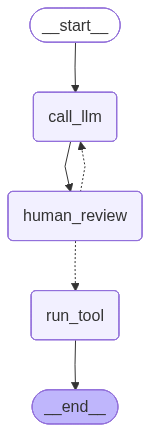

图已编译完成


In [28]:
from typing import Literal, TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt


class CollaborationState(TypedDict, total=False):
    """人机协作示例的图状态。

    user_message：用户原始输入。
    route：主管节点选择的下一个 Agent。
    draft：Agent 生成的审批草稿。
    human_decision：人工审查结果。
    result：最终输出结果。
    history：为了学习方便，手动记录节点流转轨迹。
    """

    user_message: str
    route: str
    draft: str
    human_decision: str
    result: str
    history: list[str]


def supervisor_node(state: CollaborationState) -> CollaborationState:
    """主管节点：根据用户输入，把任务路由给不同 Agent。

    真实项目中，这里可以是：
    - 规则判断
    - LLM 意图识别
    - 审批模板匹配
    - 权限过滤后的流程选择
    """
    text = state.get("user_message", "")

    if "报销" in text:
        route = "expense_agent"
    elif "请假" in text or "年假" in text:
        route = "leave_agent"
    else:
        route = "clarify"

    return {
        "route": route,
        "history": state.get("history", []) + [f"主管路由到：{route}"],
    }


def route_after_supervisor(
    state: CollaborationState,
) -> Literal["expense_agent", "leave_agent", "clarify"]:
    """条件边：根据 supervisor_node 写入的 route 决定下一个节点。"""
    return state["route"]


def expense_agent_node(state: CollaborationState) -> CollaborationState:
    """报销 Agent：这里只模拟生成一个报销草稿。"""
    return {
        "draft": "报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。",
        "history": state.get("history", []) + ["报销 Agent 生成草稿"],
    }


def leave_agent_node(state: CollaborationState) -> CollaborationState:
    """请假 Agent：这里只模拟生成一个请假草稿。"""
    return {
        "draft": "请假申请草稿：类型=年假，时间=下周一到周三，原因=个人事务。",
        "history": state.get("history", []) + ["请假 Agent 生成草稿"],
    }


def clarify_node(state: CollaborationState) -> CollaborationState:
    """兜底节点：主管无法判断时，让用户补充说明。"""
    return {
        "result": "我还不确定你要办理哪类审批，请说明是请假、报销还是其他审批。",
        "history": state.get("history", []) + ["进入澄清节点"],
    }


def human_gate_node(
    state: CollaborationState,
) -> Command[Literal["submit", "supervisor", "__end__"]]:
    """人工审查节点：审批草稿生成后，先暂停等待人工决定。

    interrupt(...) 会让图暂停，并把草稿返回给外部。
    外部再通过 Command(resume={...}) 把人工决定传回来。
    """
    review = interrupt(
        {
            "question": "是否提交这份审批草稿？",
            "draft": state["draft"],
            "options": ["approve", "revise", "reject"],
        }
    )

    action = review["action"]

    if action == "approve":
        # 批准：跳到 submit 节点。
        return Command(
            goto="submit",
            update={
                "human_decision": "approve",
                "history": state.get("history", []) + ["人工批准"],
            },
        )

    if action == "revise":
        # 修改：把新的用户意图写回 state，然后回到 supervisor 重新路由。
        new_message = review.get("message", state.get("user_message", ""))
        return Command(
            goto="supervisor",
            update={
                "user_message": new_message,
                "human_decision": "revise",
                "history": state.get("history", []) + [f"人工要求修改：{new_message}"],
            },
        )

    if action == "reject":
        # 拒绝：直接结束，不提交。
        return Command(
            goto=END,
            update={
                "human_decision": "reject",
                "result": "人工已拒绝，本次不提交。",
                "history": state.get("history", []) + ["人工拒绝"],
            },
        )

    raise ValueError(f"未知人工动作：{action}")


def submit_node(state: CollaborationState) -> CollaborationState:
    """提交节点：真实项目中这里会调用审批系统提交接口。"""
    return {
        "result": f"已提交：{state['draft']}",
        "history": state.get("history", []) + ["提交完成"],
    }


collab_workflow = StateGraph(CollaborationState)
collab_workflow.add_node("supervisor", supervisor_node)
collab_workflow.add_node("expense_agent", expense_agent_node)
collab_workflow.add_node("leave_agent", leave_agent_node)
collab_workflow.add_node("clarify", clarify_node)
collab_workflow.add_node("human_gate", human_gate_node)
collab_workflow.add_node("submit", submit_node)

# 开始后先进入主管节点，由主管决定走哪个 Agent。
collab_workflow.add_edge(START, "supervisor")
collab_workflow.add_conditional_edges("supervisor", route_after_supervisor)

# 两个 Agent 都会先生成草稿，然后进入人工审查。
collab_workflow.add_edge("expense_agent", "human_gate")
collab_workflow.add_edge("leave_agent", "human_gate")

# 澄清和提交都会结束。
collab_workflow.add_edge("clarify", END)
collab_workflow.add_edge("submit", END)

# checkpointer 是人机协作和时间旅行的基础。
# 没有 checkpointer，interrupt 暂停后就无法恢复现场，也无法查看历史检查点。
collab_graph = collab_workflow.compile(checkpointer=InMemorySaver())

from typing import Literal

from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, interrupt


@tool
def review_search(query: str) -> str:
    """模拟搜索工具。"""
    return f"搜索结果：{query} -> 北京天气晴朗，约22度，湿度30%。"


review_tools = [review_search]
review_tool_node = ToolNode(review_tools)


class ReviewState(MessagesState):
    """简单状态。"""


def call_llm_for_review(state: ReviewState):
    """为了离线稳定运行，这里模拟 LLM 生成一个工具调用。"""
    return {
        "messages": [
            AIMessage(
                content="我需要查询天气。",
                id="ai-search-request",
                tool_calls=[
                    {
                        "name": "review_search",
                        "args": {"query": "北京天气"},
                        "id": "call_search_1",
                        "type": "tool_call",
                    }
                ],
            )
        ]
    }


def human_review_node(
    state: ReviewState,
) -> Command[Literal["call_llm", "run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    human_review = interrupt(
        {
            "question": "这个工具调用正确吗？",
            "tool_call": tool_call,
        }
    )

    review_action = human_review["action"]
    review_data = human_review.get("data")

    if review_action == "continue":
        return Command(goto="run_tool")

    if review_action == "update":
        updated_message = AIMessage(
            content=last_message.content,
            id=last_message.id,
            tool_calls=[
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],
                    "args": review_data,
                    "type": "tool_call",
                }
            ],
        )
        return Command(
            goto="run_tool",
            update={"messages": [updated_message]},
        )

    if review_action == "feedback":
        feedback_message = ToolMessage(
            content=review_data,
            tool_call_id=tool_call["id"],
        )
        return Command(
            goto="call_llm",
            update={"messages": [feedback_message]},
        )

    raise ValueError(f"未知审查动作：{review_action}")


review_workflow = StateGraph(ReviewState)
review_workflow.add_node("call_llm", call_llm_for_review)
review_workflow.add_node("human_review", human_review_node)
review_workflow.add_node("run_tool", review_tool_node)

review_workflow.add_edge(START, "call_llm")
review_workflow.add_edge("call_llm", "human_review")
review_workflow.add_edge("run_tool", END)

review_graph = review_workflow.compile(checkpointer=InMemorySaver())

from IPython.display import Image, display
display(Image(review_graph.get_graph().draw_mermaid_png()))


print("图已编译完成")


### 10.2 人机协作：暂停并等待人工批准

第一次调用图时，它会执行到 `human_gate_node`，然后在 `interrupt(...)` 处暂停。

返回结果里会出现 `__interrupt__`，里面就是交给人工审查的内容。


In [29]:
# 每个 thread_id 表示一条独立会话。
# 后续 resume 必须使用同一个 thread_id，LangGraph 才知道要恢复哪条暂停的会话。
collab_config = {"configurable": {"thread_id": "collab-approve-demo"}}

first_result = collab_graph.invoke(
    {"user_message": "我要报销餐饮费 2000 元"},
    config=collab_config,
)

first_result["__interrupt__"]


[Interrupt(value={'question': '是否提交这份审批草稿？', 'draft': '报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。', 'options': ['approve', 'revise', 'reject']}, id='16c1a3adbf6b452bec879773360e47df')]

In [30]:
# 人工选择 approve 后，图会从 human_gate_node 暂停的位置继续执行。
# approve 会让流程进入 submit 节点。
approved_result = collab_graph.invoke(
    Command(resume={"action": "approve"}),
    config=collab_config,
)

approved_result["result"], approved_result["history"]


('已提交：报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。',
 ['主管路由到：expense_agent', '报销 Agent 生成草稿', '人工批准', '提交完成'])

### 10.3 时间旅行：查看历史检查点

`checkpointer` 会保存每一步的状态。`get_state_history(config)` 可以查看这条 `thread_id` 的历史状态。

下面只打印每个检查点的 `next` 和关键字段，方便观察图是怎么一步步走的。


In [31]:
history = list(collab_graph.get_state_history(collab_config))

for index, snapshot in enumerate(history):
    print(f"检查点 {index}")
    print("  下一步节点 next:", snapshot.next)
    print("  当前草稿 draft:", snapshot.values.get("draft"))
    print("  人工决定 human_decision:", snapshot.values.get("human_decision"))
    print("  结果 result:", snapshot.values.get("result"))
    print("  历史 history:", snapshot.values.get("history"))
    print()


检查点 0
  下一步节点 next: ()
  当前草稿 draft: 报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。
  人工决定 human_decision: approve
  结果 result: 已提交：报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。
  历史 history: ['主管路由到：expense_agent', '报销 Agent 生成草稿', '人工批准', '提交完成']

检查点 1
  下一步节点 next: ('submit',)
  当前草稿 draft: 报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。
  人工决定 human_decision: approve
  结果 result: None
  历史 history: ['主管路由到：expense_agent', '报销 Agent 生成草稿', '人工批准']

检查点 2
  下一步节点 next: ('human_gate',)
  当前草稿 draft: 报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。
  人工决定 human_decision: None
  结果 result: None
  历史 history: ['主管路由到：expense_agent', '报销 Agent 生成草稿']

检查点 3
  下一步节点 next: ('expense_agent',)
  当前草稿 draft: None
  人工决定 human_decision: None
  结果 result: None
  历史 history: ['主管路由到：expense_agent']

检查点 4
  下一步节点 next: ('supervisor',)
  当前草稿 draft: None
  人工决定 human_decision: None
  结果 result: None
  历史 history: None

检查点 5
  下一步节点 next: ('__start__',)
  当前草稿 draft: None
  人工决定 human_decision: None
  结果 result: None
  历史 history: None



### 10.4 时间旅行：从旧状态分叉出另一条路径

一种容易理解的时间旅行方式是：

1. 找到某个旧检查点，比如“已经生成草稿，正在等待人工审查”。
2. 取出这个检查点里的 `values`。
3. 换一个新的 `thread_id`，把旧状态写进去。
4. 从这个新线程继续执行，走出另一条路径。

下面演示：原线程选择了 `approve`，新分支从同一个草稿状态出发，选择 `reject`。


In [32]:
# 找到 next 是 human_gate 的检查点：说明当时已经生成草稿，下一步正准备进入人工审查。
human_gate_snapshot = next(
    snapshot
    for snapshot in history
    if snapshot.next == ("human_gate",)
)

# 新开一条 thread_id，表示这是一条分支会话，不影响原来的 approve 结果。
branch_config = {"configurable": {"thread_id": "collab-reject-branch"}}

# 把旧检查点的状态复制到新线程。
# as_node="expense_agent" 的意思是：这些状态看起来像 expense_agent 节点刚刚写入的结果，
# 所以下一步会继续走到它后面的 human_gate 节点。
branch_config = collab_graph.update_state(
    branch_config,
    human_gate_snapshot.values,
    as_node="expense_agent",
)

# 先运行到 human_gate，让它再次 interrupt。
branch_interrupt = collab_graph.invoke(None, config=branch_config)
branch_interrupt["__interrupt__"]


[Interrupt(value={'question': '是否提交这份审批草稿？', 'draft': '报销申请草稿：类型=餐饮费，金额=2000，事由=客户招待。', 'options': ['approve', 'revise', 'reject']}, id='031e302f703e9da90a89ea1fce168676')]

In [33]:
# 在分支线程里选择 reject。
# 这不会影响原线程 collab-approve-demo 的提交结果。
rejected_branch = collab_graph.invoke(
    Command(resume={"action": "reject"}),
    config=branch_config,
)

rejected_branch["result"], rejected_branch["history"]


('人工已拒绝，本次不提交。', ['主管路由到：expense_agent', '报销 Agent 生成草稿', '人工拒绝'])

### 10.5 多智能体：主管路由到不同 Agent

上面的 `supervisor -> expense_agent / leave_agent` 就是一个最小多智能体模式。

- `supervisor`：负责判断任务类型，相当于主管或路由器。
- `expense_agent`：只负责报销草稿。
- `leave_agent`：只负责请假草稿。
- `human_gate`：统一做人审和确认。

在真实项目中，每个 Agent 可以是一个子图，也可以是一个带工具的 Agent。


In [ ]:
leave_config = {"configurable": {"thread_id": "collab-leave-demo"}}

leave_first = collab_graph.invoke(
    {"user_message": "我要请年假，下周一到周三"},
    config=leave_config,
)

# 可以看到主管把任务路由给 leave_agent，生成的是请假草稿。
leave_first["__interrupt__"]


## 11. 常见错误

| 问题 | 原因 | 处理 |
| --- | --- | --- |
| `create_react_agent` 弃用警告 | 还在从 `langgraph.prebuilt` 导入旧入口 | 改用 `from langchain.agents import create_agent` |
| 工具里拿不到 context | 直接调用 `tool.invoke`，没有走 Agent 工具节点 | 用 `agent.invoke(..., context=Context(...))` |
| Agent 不记得前文 | 没有 checkpointer 或 `thread_id` 变化 | 使用 `checkpointer + thread_id` |
| 节点返回值错误 | 节点没有返回状态更新 dict | 返回 `{"字段": 值}` |
| 列表被覆盖 | 没有 reducer | 使用 `Annotated[list[T], add]` 或消息 reducer |


## 12. 参考链接

- LangGraph 快速入门: <https://langgraph.com.cn/agents/agents.1.html>
- LangGraph 图 API 概念: <https://langgraph.com.cn/concepts/low_level.1.html>
- LangGraph 持久化: <https://langgraph.com.cn/concepts/persistence.1.html>
- LangGraph 记忆概念: <https://langgraph.com.cn/concepts/memory.1.html>
- LangGraph 人工参与循环: <https://langgraph.com.cn/concepts/human_in_the_loop.1.html>
- LangGraph 多代理系统: <https://langgraph.com.cn/concepts/multi_agent.1.html>
